# Supply chain and Logistics Machine Learning project

In [7]:
import pandas as pd


In [8]:
df = pd.read_csv("/content/supply_chain_data_2026.csv")

### Data exploration

In [9]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days
0,SC-10000,16-10-2025,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,42
1,SC-10001,24-04-2024,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,41
2,SC-10002,26-01-2024,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,12
3,SC-10003,08-10-2024,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,54
4,SC-10004,07-09-2024,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,1


In [10]:
df.shape

(5000, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage:

In [12]:
# Checking null values
df.isnull().sum()


,0
Shipment_ID,0
Date,0
Origin_Port,0
Destination_Port,0
Transport_Mode,0
Product_Category,0
Distance_km,0
Weight_MT,0
Fuel_Price_Index,0
Geopolitical_Risk_Score,0


In [13]:
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.84100
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.41048
min,500.170000,1.030000,1.200000,0.000000,0.500000,1.00000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,3.00000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,9.00000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,22.00000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,237.00000


In [14]:
# checking duplicate values
df.duplicated().sum()

np.int64(0)

### Feature engineering


In [15]:
# converting date into datatime format
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_4255/2745122779.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [16]:
# Creating a new feature month
df['Month'] = df['Date'].dt.month

In [17]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Month
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,42,10
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,41,4
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,12,1
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,54,10
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,1,9


### Feature selection

In [18]:
# Target/ dependent variable
y = df['Lead_Time_Days']

In [19]:
# Independent variables
x = df.drop(
    columns = ['Lead_Time_Days',
             'Shipment_ID',
             'Date'])


In [20]:
#final set of features to train the model
x.columns

Index(['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category',
       'Distance_km', 'Weight_MT', 'Fuel_Price_Index',
       'Geopolitical_Risk_Score', 'Weather_Condition',
       'Carrier_Reliability_Score', 'Month'],
      dtype='object')

### One Hot Encoding

In [21]:
x = pd.get_dummies(x, drop_first=True)

#This will automatically identify all object/category columns
# and perform one-hot encoding on them and leave
# numeric columns unchanged.

In [22]:
# Snapshot the data after one-hot encoding
x.head()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Month,Origin_Port_Busan,Origin_Port_Dubai,Origin_Port_Hamburg,Origin_Port_Los Angeles,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
0,5930.83,197.42,2.43,5.0,0.865,10,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,14285.36,237.24,2.30,7.5,0.592,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,11113.91,427.42,1.78,5.6,0.673,1,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,9180.55,170.66,3.20,0.8,0.832,10,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,2762.27,434.96,2.77,1.9,0.741,9,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False


### Train-Test split

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
  x,
  y,
  test_size=0.2, # testsize would be 20%
  random_state= 49
  )

# By setting random_state = 49, we are telling Python:
# Use the same random pattern every time this code runs.
# This makes it easier to reproduce our work
# and compare models fairly

### Model Building

#### Linear Regression

In [25]:
# linear regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

LinearRegression()

In [26]:
# Making predictions

pred_lr = lr.predict(x_test)

#### Evaluating Model performance - Linear regression model

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error ,r2_score

mae_lr = mean_absolute_error(y_test, pred_lr)
mae_lr

12.33394402754733

In [30]:
rmse_lr = mean_squared_error(y_test, pred_lr)**0.5
rmse_lr

18.973088597144553

In [31]:
r2_lr = r2_score(y_test, pred_lr)
r2_lr

0.6245064553661729

#### Sanity check predictions

In [32]:
pred_lr

array([-1.26061152e+01,  3.61945285e+01,  6.57202520e+01,  3.03578977e+01,
        6.81006709e+01,  4.48705742e+01,  7.09146212e+01, -9.74017963e+00,
       -6.43319214e+00,  1.80319502e+01,  2.82866720e+01,  8.58580142e+00,
        2.04191542e+01,  1.91462179e+01,  6.12540197e+01,  3.12670498e+01,
       -1.47578792e+01,  3.98536734e+01,  2.69885436e+01,  5.21026714e+01,
        2.09143391e+01,  1.54614221e+01,  5.65679856e+00,  7.12412483e+01,
        8.43573849e+00,  8.55644880e+00,  1.40628203e+01, -6.95429036e+00,
       -5.64928395e+00,  1.17852864e+01,  9.24539122e+00,  4.67072614e+01,
        4.05900510e+00,  6.28012505e+01,  5.88374443e+00,  3.48984063e+00,
       -1.51141298e+00,  4.15547800e+01,  1.21619391e+01,  4.05647320e+00,
        3.67943147e+01,  4.74353800e+01, -1.24347643e+01,  2.32281803e+01,
       -7.60663966e+00,  1.29024946e+01,  6.71879003e+01,  3.07523214e+01,
       -1.00548285e+01,  5.27466216e+01,  8.46081131e+00, -1.86480882e+00,
        3.00050581e+01,  

In [33]:
import numpy as np
np.sum(pred_lr < 0)

np.int64(229)

<Axes: xlabel='Lead_Time_Days', ylabel='Count'>

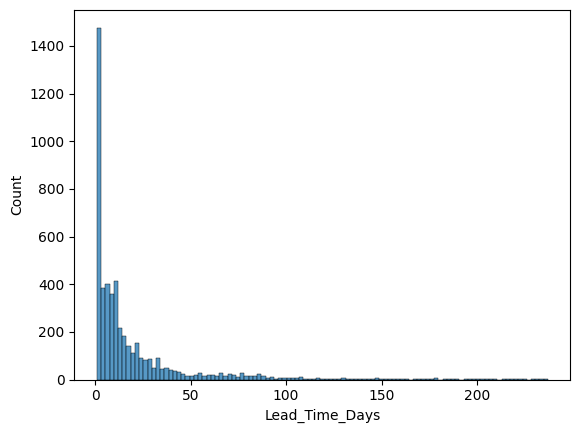

In [34]:
# Distribution of lead_time_days

import seaborn as sns
sns.histplot(df['Lead_Time_Days'])

In [35]:
# Clip the  negative predictions in pred_lr , clip them to 1

pred_lr_clipped = np.clip(pred_lr, a_min=1, a_max=None)

In [36]:
pred_lr_clipped

array([ 1.        , 36.19452852, 65.72025195, 30.35789773, 68.10067091,
       44.8705742 , 70.91462119,  1.        ,  1.        , 18.03195025,
       28.28667196,  8.58580142, 20.41915416, 19.14621795, 61.2540197 ,
       31.2670498 ,  1.        , 39.85367339, 26.98854358, 52.10267136,
       20.91433909, 15.46142211,  5.65679856, 71.24124835,  8.43573849,
        8.5564488 , 14.06282031,  1.        ,  1.        , 11.78528643,
        9.24539122, 46.70726143,  4.0590051 , 62.80125054,  5.88374443,
        3.48984063,  1.        , 41.55477997, 12.16193906,  4.0564732 ,
       36.79431471, 47.43538   ,  1.        , 23.22818031,  1.        ,
       12.90249462, 67.18790033, 30.75232141,  1.        , 52.74662157,
        8.46081131,  1.        , 30.00505806, 51.378182  , 46.94822288,
        8.95390891,  4.91402178, 31.98314048, 43.58403295, 20.05778583,
       53.19867667,  1.        ,  1.        , 92.41531097,  1.        ,
       33.73088578,  6.93636915, 47.967041  , 68.69986805, 42.22

#### Decision tree model

In [37]:
# Model 2: Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(x_train, y_train)



DecisionTreeRegressor()

In [39]:
#predictions using decision tree model

pred_dt = dt.predict(x_test)

In [40]:
# Sanity Check Predictions

np.sum(pred_dt < 0)

np.int64(0)

#### Evaluate model performance -Decision tree model

In [44]:
mae_dt = mean_absolute_error(y_test, pred_dt)
mae_dt

1.502

In [43]:
rmse_dt = mean_squared_error(y_test,pred_dt) ** 0.5
rmse_dt

3.0974182797936733

In [45]:
r2_dt = r2_score(y_test, pred_dt)
r2_dt

0.9899924879926467

#### Feature importance

In [47]:
#feature importance of decision tree model

importance = pd.DataFrame(
    {
        "Feature": x_train.columns,
        "Importance": dt.feature_importances_
    }
)

importance.sort_values(
    by="Importance",
    ascending=False
).head(5)

,Feature,Importance
29,Weather_Condition_Hurricane,0.291255
0,Distance_km,0.275260
23,Transport_Mode_Sea,0.273181
22,Transport_Mode_Road,0.064691
21,Transport_Mode_Rail,0.043778
